In [1]:
import os
os.chdir('../..')

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np
from loguru import logger
from sklearn.decomposition import PCA
import polars as pl

from src.descriptors import SOAPDescriptor, ACSFDescriptor
from src.clusters import ClusterAnalysis
from src.datasets import QM9Dataset

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_soap()

2026-02-15 09:18:42.291 | INFO     | src.datasets:load:74 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-02-15 09:18:42.305 | INFO     | src.features:compute_soap:125 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-02-15 09:18:50.039 | SUCCESS  | src.datasets:add_soap:193 - Added SOAP embeddings.


In [5]:
qm9.df

mol_id,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding
str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64]
"""qm9_0""","""C""","""[C]""",5,"""Acyclic""",16.043,0.6361,0.0,1,0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0.184413, 0.478464, … 0.0]"
"""qm9_1""","""N""","""[N]""",4,"""Acyclic""",17.031,0.162,35.0,1,0,0,0,0.0,1,1,0,0,0,0,0,0,0,0,0,0,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0.170095, 0.427155, … 0.0]"
"""qm9_2""","""O""","""[O]""",3,"""Acyclic""",18.015,-0.8247,31.5,1,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0.150713, 0.392522, … 0.0]"
"""qm9_3""","""C#C""","""[C][#C]""",4,"""Acyclic""",26.038,0.2494,0.0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0.116808, 0.322429, … 0.0]"
"""qm9_4""","""C#N""","""[C][#N]""",3,"""Acyclic""",27.026,0.13978,23.79,2,0,0,0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0.077737, 0.214865, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,"""Aliphatic Ring""",97.117,0.0625,29.1,7,1,0,0,0.4,1,1,0,0,0,0,1,0,0,0,0,0,2,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821,"[0.115699, 0.317575, … 0.0]"
"""qm9_2011""","""O=C1C=CCCO1""","""[O][=C][C][=C][C][C][O][Ring1]…",13,"""Aliphatic Ring""",98.101,0.4895,26.3,7,1,0,0,0.4,0,2,0,0,0,0,0,0,1,0,1,0,2,4.8544,56.209999,-7.159316,-1.257166,5.90215,655.236389,2.820787,-9374.298828,-9374.142578,-9374.116211,-9375.104492,21.473,-58.082684,-58.426769,-58.735184,-54.355564,5.15103,2.69583,1.85565,"[0.106967, 0.292443, … 0.0]"
"""qm9_2012""","""[NH-][C@H]1CCCCO1""","""[NH1-1][C@H1][C][C][C][C][O][R…",16,"""Aliphatic Ring""",100.141,1.5652,33.03,7,1,0,0,1.0,0,1,0,0,0,0,0,0,0,0,1,0,2,3.2084,62.029999,-6.908971,0.634025,7.542996,719.927979,3.796587,-8865.521484,-8865.349609,-8865.324219,-8866.344727,23.990999,-65.773956,-66.218506,-66.604065,-61.192863,4.58056,2.56496,1.77558,"[0.13575, 0.370947, … 0.0]"


In [6]:
def analyze_soap_sensitivity(loader, r_cuts=[float(i) for i in range(2, 9)]):
    """
    Runs the Grassmann Stress Test using SOAP with different cutoff radii.
    Updated to handle inhomogeneous shapes and use the ClusterAnalysis framework.
    """
    # 1. Generate the Perturbed Frames
    frames = loader.run_stress_test()
    true_labels = [f.info['mol_id'] for f in frames]
    n_clusters = len(set(true_labels))
    #n_clusters = 5

    ari_scores = []
    
    print("--- SOAP Sensitivity Analysis (Tuning r_cut) ---")
    
    for r in r_cuts:
        soap_desc = SOAPDescriptor(loader, r_cut=r, n_max=8, l_max=6)
        
        features = []
        valid_indices = []
        
        for idx, frame in enumerate(frames):
            try:
                vec = soap_desc.soap.create(frame).ravel()
                features.append(vec)
                valid_indices.append(idx)
            except Exception as e:
                continue

        if not features:
            print(f"r_cut = {r:.1f} Å -> All embeddings failed.")
            ari_scores.append(0)
            continue

        lengths = [len(f) for f in features]
        max_len = max(lengths)
        
        X_list = []
        for f in features:
            if len(f) < max_len:
                pad = np.zeros(max_len)
                pad[:len(f)] = f
                X_list.append(pad)
            else:
                X_list.append(f)
        
        X = np.array(X_list)
        current_true_labels = [true_labels[i] for i in valid_indices]

        analyzer = ClusterAnalysis(X, true_labels=current_true_labels)
        preds = analyzer.run(method='kmeans', n_clusters=n_clusters)
        
        metrics = analyzer.evaluate()
        score = metrics.get('ARI', 0)
        ari_scores.append(score)

        if r > 7.5:
            analyzer.plot_pca()
        
        #print(f"r_cut = {r:.1f} Å -> ARI = {score:.4f} (Features: {X.shape[1]})")

    # 3. Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(r_cuts, ari_scores, marker='o', linestyle='-', color='#2c3e50', linewidth=2)
    
    # Highlight the 6.0 Å target from your Phase 2 deliverable
    plt.axvline(x=6.0, color='#e74c3c', linestyle='--', label='Phase 2 Target (6.0 Å)')
    
    plt.title("SOAP Sensitivity: Impact of Cutoff Radius on Structural Resolution", fontsize=12, fontweight='bold')
    plt.xlabel("Cutoff Radius ($r_{cut}$) [Å]")
    plt.ylabel("Clustering Accuracy (ARI)")
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()



    return r_cuts, ari_scores

--- SOAP Sensitivity Analysis (Tuning r_cut) ---
--- Running KMEANS ---
Found 10 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 1.0000
Silhouette Score: 0.6984
Calinski-Harabasz Score: 330.0810
--- Running KMEANS ---
Found 10 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 1.0000
Silhouette Score: 0.7129
Calinski-Harabasz Score: 371.5528
--- Running KMEANS ---
Found 10 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 1.0000
Silhouette Score: 0.7183
Calinski-Harabasz Score: 398.1387
--- Running KMEANS ---
Found 10 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 1.0000
Silhouette Score: 0.7190
Calinski-Harabasz Score: 401.9301
--- Running KMEANS ---
Found 10 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 1.0000
Silhouette Score: 0.7188
Calinski-Harabasz Score: 394.6867
--- Running KMEANS ---
Found 10 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 1.0000
Silhouette Score: 0.7180
Calinski-Hara

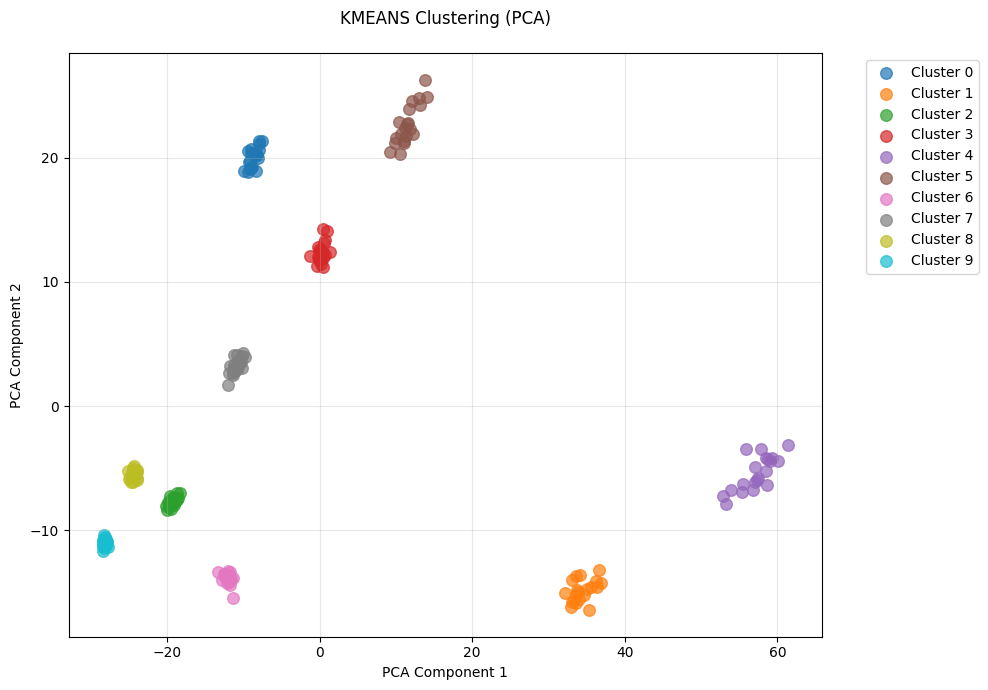

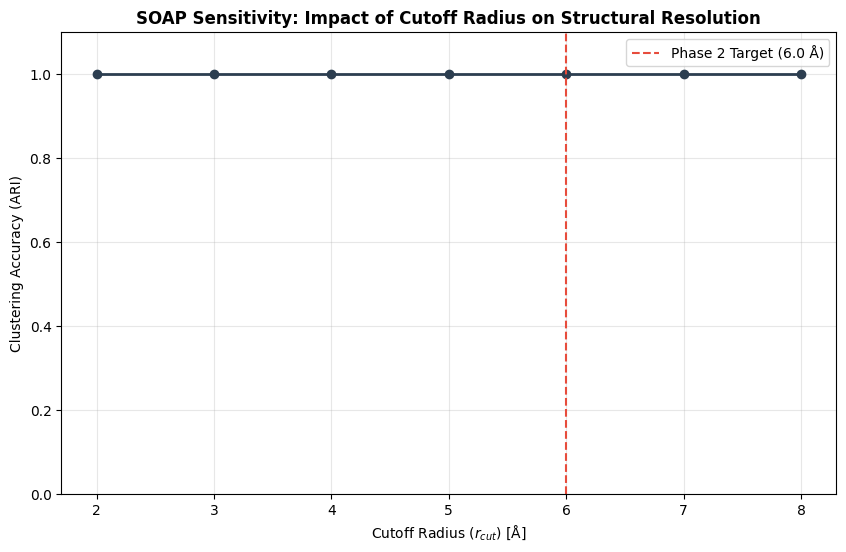

([2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

In [7]:
analyze_soap_sensitivity(qm9)

# ACSF

In [8]:
qm9.add_acsf()
print(qm9.df.select(["mol_id", "acsf_embedding"]).head(5))

2026-02-15 09:19:39.072 | INFO     | src.features:compute_acsf:155 - Computing ACSF (rcut=6.0)...
2026-02-15 09:19:45.723 | SUCCESS  | src.datasets:add_acsf:203 - Added ACSF embeddings.


shape: (5, 2)
┌────────┬─────────────────────────────┐
│ mol_id ┆ acsf_embedding              │
│ ---    ┆ ---                         │
│ str    ┆ list[f64]                   │
╞════════╪═════════════════════════════╡
│ qm9_0  ┆ [2.650031, 1.765813, … 0.0] │
│ qm9_1  ┆ [1.94162, 1.53645, … 0.0]   │
│ qm9_2  ┆ [1.190363, 1.052614, … 0.0] │
│ qm9_3  ┆ [1.012563, 0.530161, … 0.0] │
│ qm9_4  ┆ [0.540542, 0.358622, … 0.0] │
└────────┴─────────────────────────────┘


# Clustering

In [9]:
cols = [
    "mol_weight", "logp", "tpsa", "num_heavy_atoms", "num_rings", 
    "num_aromatic_rings", "num_rotatable_bonds", "fraction_csp3", 
    "h_bond_donors", "h_bond_acceptors", "mu", "alpha", "homo", 
    "lumo", "gap", "r2", "zpve", "u0", "u", "h", "g", "cv"
]

qm9.apply_scaling(cols, mode="fit_transform")

2026-02-15 09:19:49.887 | INFO     | src.datasets:apply_scaling:261 - Fitting and transforming columns: ['mol_weight', 'logp', 'tpsa', 'num_heavy_atoms', 'num_rings', 'num_aromatic_rings', 'num_rotatable_bonds', 'fraction_csp3', 'h_bond_donors', 'h_bond_acceptors', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u', 'h', 'g', 'cv']


In [10]:
qm9.df['soap_embedding'].shape

(2000,)

In [11]:
qm9.df.filter(pl.col('soap_embedding').is_null()).shape

(23, 47)

In [12]:
qm9.df.filter(pl.col('soap_embedding').is_null())

mol_id,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding,acsf_embedding
str,str,str,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64],list[f64]
"""qm9_641""","""C[C@H]1[C@H]2C[C@@H]1C2""","""[C][C@H1][C@H1][C][C@@H1][Ring…",16,"""Aliphatic Ring""",-0.856186,1.488233,-1.716697,-0.619075,3.084425,-0.457373,-0.847993,1.145644,-0.994729,-1.822891,0,0,0,0,0,0,0,0,0,0,0,-1.558179,0.554222,-1.381135,1.729189,2.414628,-0.908877,0.89332,1.587307,1.587295,1.587295,1.587318,-0.620417,-64.338097,-64.807297,-65.192886,-59.83828,6.86385,3.29296,3.06483,null,null
"""qm9_643""","""O[C@H]1[C@H]2C[C@@H]1C2""","""[O][C@H1][C@H1][C][C@@H1][Ring…",14,"""Aliphatic Ring""",-0.68228,0.118978,-0.663591,-0.619075,3.084425,-0.457373,-0.847993,1.145644,0.283843,-0.72078,0,1,0,0,0,0,0,0,0,0,1,-0.657806,-0.25581,-0.074635,1.132419,1.132201,-1.130228,0.187333,0.822367,0.822339,0.822339,0.822404,-0.86629,-56.448883,-56.849136,-57.183289,-52.5093,7.03621,3.45239,3.19279,null,null
"""qm9_656""","""C[C@H]1[C@H]2CO[C@@H]12""","""[C][C@H1][C@H1][C][O][C@@H1][R…",14,"""Aliphatic Ring""",-0.68228,0.40245,-1.236215,-0.619075,1.743079,-0.457373,-0.847993,1.145644,-0.994729,-0.72078,0,0,0,0,0,0,0,0,1,0,1,-0.53787,-0.312914,0.642869,1.277579,0.879984,-1.089716,0.156886,0.822157,0.822139,0.822139,0.822183,-0.750953,-56.717079,-57.105412,-57.439568,-52.792545,6.35478,3.46444,3.31917,null,null
"""qm9_672""","""O=C1C[C@H]2CN12""","""[O][=C][C][C@H1][C][N][Ring1][…",11,"""Aliphatic Ring""",-0.772937,-0.725211,-0.6714,-0.619075,1.743079,-0.457373,-0.847993,0.397702,-0.994729,-0.72078,0,0,0,0,1,0,0,0,0,0,2,0.940083,-0.972783,0.018177,-0.629666,-0.613918,-1.303272,-0.884279,0.505296,0.505258,0.505258,0.505342,-1.342006,-47.083103,-47.374672,-47.631687,-43.998039,7.87898,3.80242,3.00635,null,null
"""qm9_685""","""C1[C@H]2[C@@H]3C[C@H]2[C@H]13""","""[C][C@H1][C@@H1][C][C@H1][Ring…",14,"""Aliphatic Ring""",-1.033971,1.06936,-1.716697,-0.619075,5.767117,-0.457373,-0.847993,1.145644,-0.994729,-1.822891,0,0,0,0,0,0,0,0,0,0,0,-1.645165,0.179873,-1.384704,1.763463,2.451491,-1.381165,0.203545,1.613501,1.613467,1.613467,1.613536,-1.357412,-58.087227,-58.507835,-58.841991,-54.135998,8.06963,4.05535,4.05535,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_1849""","""O[C@H]1[C@H]2C[C@]1(O)C2""","""[O][C@H1][C@H1][C][C@][Ring1][…",15,"""Aliphatic Ring""",0.728627,-0.831405,0.389515,0.652126,3.084425,-0.457373,-0.847993,1.145644,1.562415,0.38133,0,2,0,0,0,0,0,0,0,0,2,-0.339083,0.148148,-0.156737,1.084032,1.126381,-0.402727,0.309477,-0.779272,-0.779292,-0.779292,-0.779229,0.171124,-60.815197,-61.218956,-61.5788,-56.512882,3.66332,3.02423,2.27602,null,null
"""qm9_1856""","""C[C@@]12CC(=O)N1C2""","""[C][C@@][C][C][=Branch1][C][=O…",14,"""Aliphatic Ring""",0.464065,-0.306338,-0.6714,0.652126,1.743079,-0.457373,-0.847993,0.547291,-0.994729,-0.72078,0,0,0,0,1,0,0,0,0,0,2,1.148227,0.233805,0.168103,-0.549022,-0.619738,-0.212603,-0.058455,-0.331399,-0.331413,-0.331413,-0.331374,-0.074541,-59.33234,-59.697239,-60.031368,-55.3256,5.86536,2.25478,1.97308,null,null
"""qm9_1952""","""N#C[C@]12C[C@H](C1)N2""","""[N][#C][C@][C][C@H1][Branch1][…",13,"""Aliphatic Ring""",0.199504,-0.281233,0.147972,0.652126,3.084425,-0.457373,-0.847993,0.547291,0.283843,0.38133,0,0,0,0,0,0,0,0,0,0,2,1.280299,0.397714,-0.428031,-0.24862,-0.006656,-0.311013,-0.327736,0.118426,0.118399,0.118399,0.118456,-0.651645,-55.354797,-55.704327,-56.012714,-51.615028,6.33166,2.08679,2.0783,null,null


In [13]:
def clustering(do_pca=False):

    # List of the new fragment columns we added to the mol_dict
    fragment_cols = [c for c in qm9.df.columns if c.startswith("fr_")]

    embeddings = ['soap_embedding', 'acsf_embedding']
    methods = ['kmeans', 'hierarchical', 'dbscan']

    for embedding in embeddings:
        for method in methods:
            # 1. Prepare Data
            df_clean = qm9.df.filter(pl.col(embedding).is_not_null())
            X_raw = np.array(df_clean[embedding].to_list())
            
            if do_pca:
                pca_reduction = PCA(n_components=0.95) 
                X_features = pca_reduction.fit_transform(X_raw)
                actual_variance = np.sum(pca_reduction.explained_variance_ratio_) * 100
                logger.info(
                    f"PCA reduced {embedding} from {X_raw.shape[1]} to {X_features.shape[1]} dims. "
                    f"Exact variance kept: {actual_variance:.2f}%"
                )

            else:
                X_features = X_raw

            # 2. Run Framework
            analyzer = ClusterAnalysis(
                X_features, 
                true_labels=df_clean["structure_class"], 
                meta_df=df_clean
            )
            
            if method == 'dbscan':
                labels = analyzer.run(method='dbscan', eps=0.5, min_samples=5)
            else:
                labels = analyzer.run(method=method, n_clusters=3)
                
            analyzer.evaluate()

            # --- 3. Custom Visualization with Dominant Motif Labels ---
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(X_features)
            
            plt.figure(figsize=(10, 8))
            plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab20', alpha=0.4, s=30)
            
            # Calculate cluster composition
            temp_df = df_clean.with_columns(pl.Series("cluster_id", labels))
            
            # We aggregate both the Structure Class AND the sums of all fragment columns
            summary = (
                temp_df.group_by("cluster_id")
                .agg([
                    pl.col("structure_class").mode().first().alias("dom_class"),
                    ((pl.col("structure_class") == pl.col("structure_class").mode().first()).sum() / pl.len() * 100).alias("dom_perc"),
                    *[pl.col(c).sum().alias(c) for c in fragment_cols]
                ])
                .sort("cluster_id")
            )

            # Annotate dominant class at the center of each cluster
            unique_labels = sorted(list(set(labels)))
            for cluster in unique_labels:
                if cluster == -1: continue 

                mask = (labels == cluster)
                center_x = np.mean(X_pca[mask, 0])
                center_y = np.mean(X_pca[mask, 1])
                
                row = summary.filter(pl.col("cluster_id") == cluster)
                if not row.is_empty():
                    
                    # --- FIXED: Robust Motif Detection ---
                    best_motif_clean = None
                    best_count = 0
                    
                    # Only try to find a motif if fragment columns actually exist in the data
                    if fragment_cols:
                        current_frags = row.select(fragment_cols)
                        # Create list of (name, count) pairs
                        frag_counts = [(c, current_frags[c][0]) for c in fragment_cols]
                        
                        # Ensure the list isn't empty before calling max()
                        if frag_counts:
                            best_motif_raw, best_count = max(frag_counts, key=lambda x: x[1])
                            best_motif_clean = best_motif_raw.replace("fr_", "").replace("_", " ").title()

                    # Create the multi-line label
                    # Only show the motif if one was found and its count is > 0
                    if best_motif_clean and best_count > 0:
                        label_text = f"{row['dom_class'][0]} ({row['dom_perc'][0]:.0f}%)\nMotif: {best_motif_clean}"
                    else:
                        # Fallback to just the structure class
                        label_text = f"{row['dom_class'][0]}\n{row['dom_perc'][0]:.0f}%"
                    
                    plt.text(
                        center_x, center_y, 
                        label_text, 
                        fontsize=8, weight='bold', ha='center', va='center',
                        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3')
                    )

            plt.title(f"{embedding.upper()} Clusters ({method.upper()})\nLabeled by Class & Dominant Motif", fontsize=13, fontweight='bold')
            plt.xlabel("PCA 1")
            plt.ylabel("PCA 2")
            plt.grid(True, alpha=0.2)
            plt.show()


--- Running KMEANS ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.1018
Silhouette Score: 0.2659
Calinski-Harabasz Score: 1385.5575


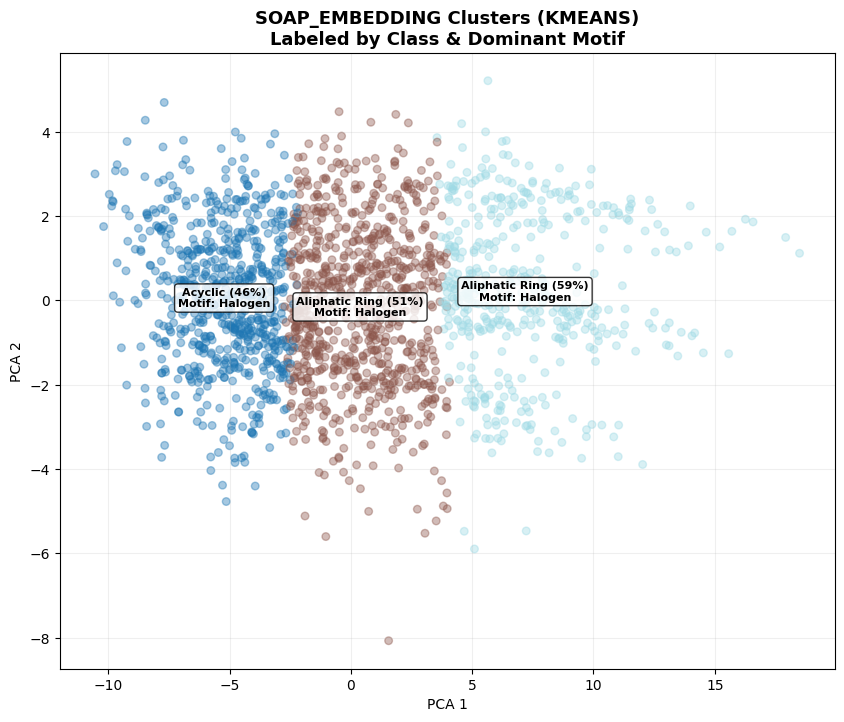

--- Running HIERARCHICAL ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0990
Silhouette Score: 0.2818
Calinski-Harabasz Score: 1218.7686


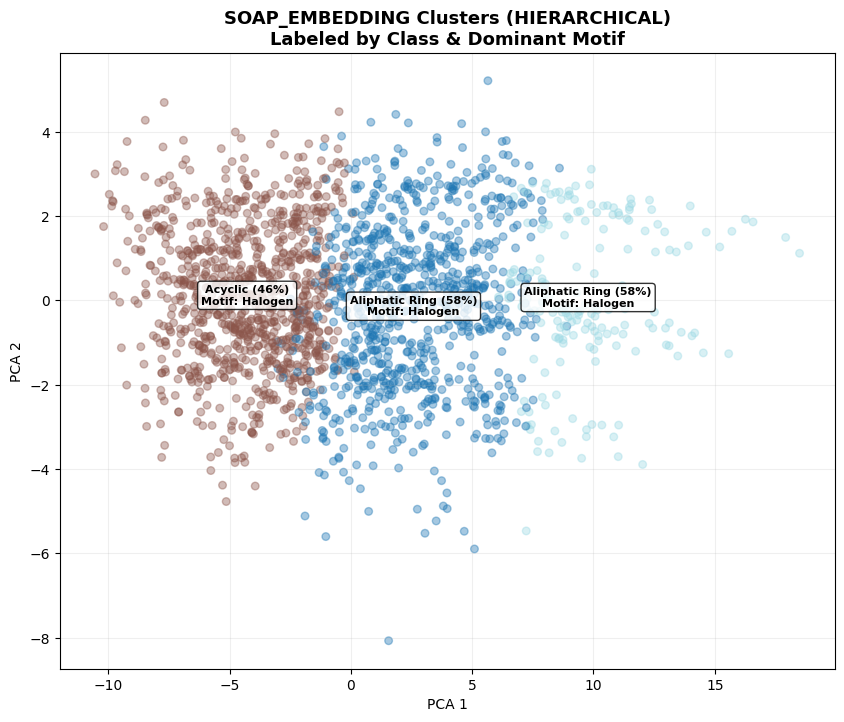

--- Running DBSCAN ---
Found 0 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0000
Not enough clusters for internal metrics.


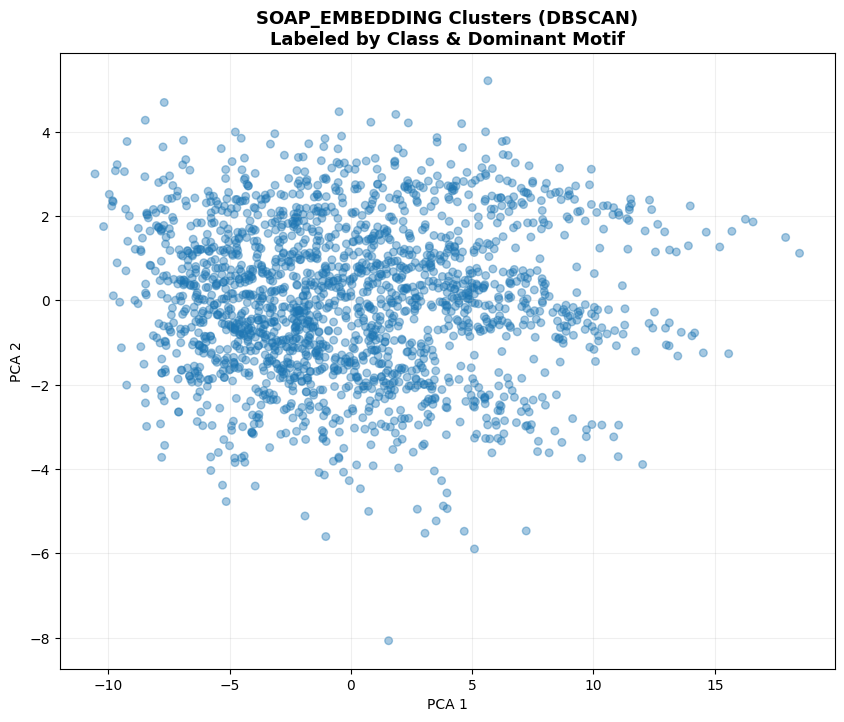

--- Running KMEANS ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.1171
Silhouette Score: 0.3015
Calinski-Harabasz Score: 1601.0030


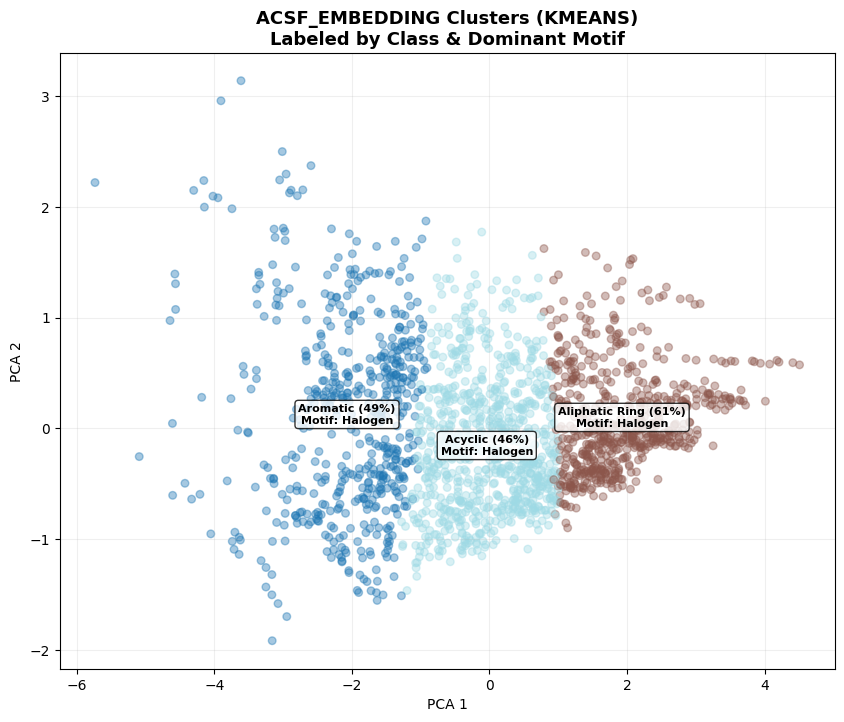

--- Running HIERARCHICAL ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0728
Silhouette Score: 0.2647
Calinski-Harabasz Score: 1382.4321


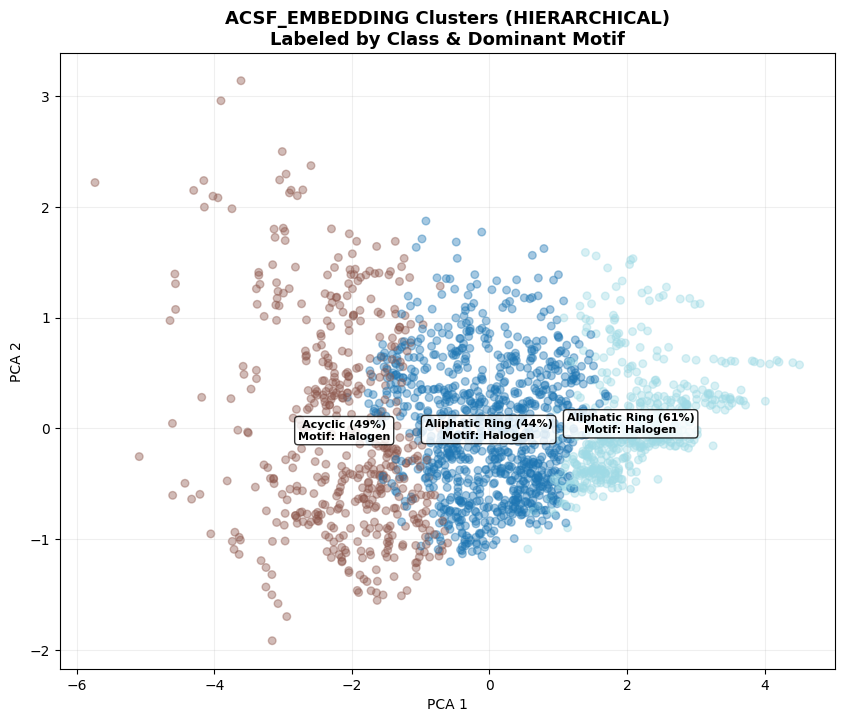

--- Running DBSCAN ---
Found 14 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0376
Silhouette Score: -0.2911
Calinski-Harabasz Score: 34.1623


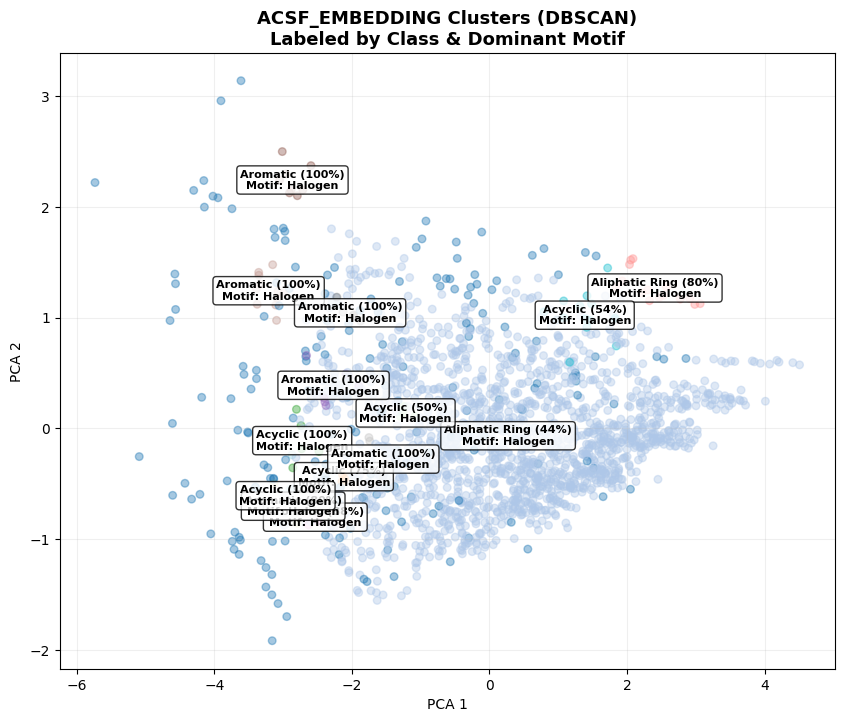

In [14]:
clustering(do_pca=False)

2026-02-11 15:28:50.609 | INFO     | __main__:clustering:19 - PCA reduced soap_embedding from 5740 to 10 dims. Exact variance kept: 95.37%


--- Running KMEANS ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.1018
Silhouette Score: 0.2872
Calinski-Harabasz Score: 1557.1155


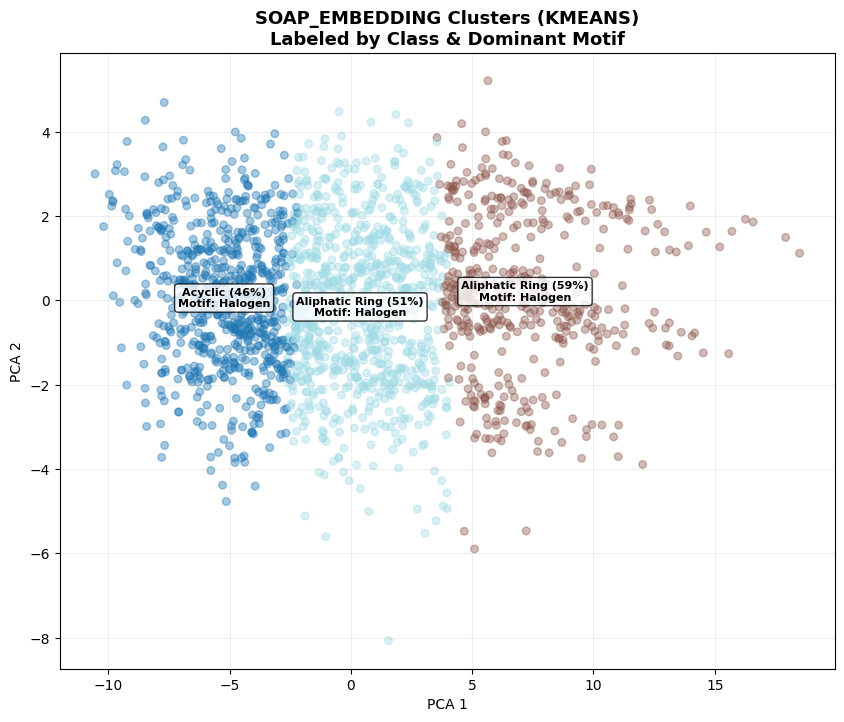

2026-02-11 15:28:54.269 | INFO     | __main__:clustering:19 - PCA reduced soap_embedding from 5740 to 10 dims. Exact variance kept: 95.37%


--- Running HIERARCHICAL ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.1094
Silhouette Score: 0.2576
Calinski-Harabasz Score: 1385.7223


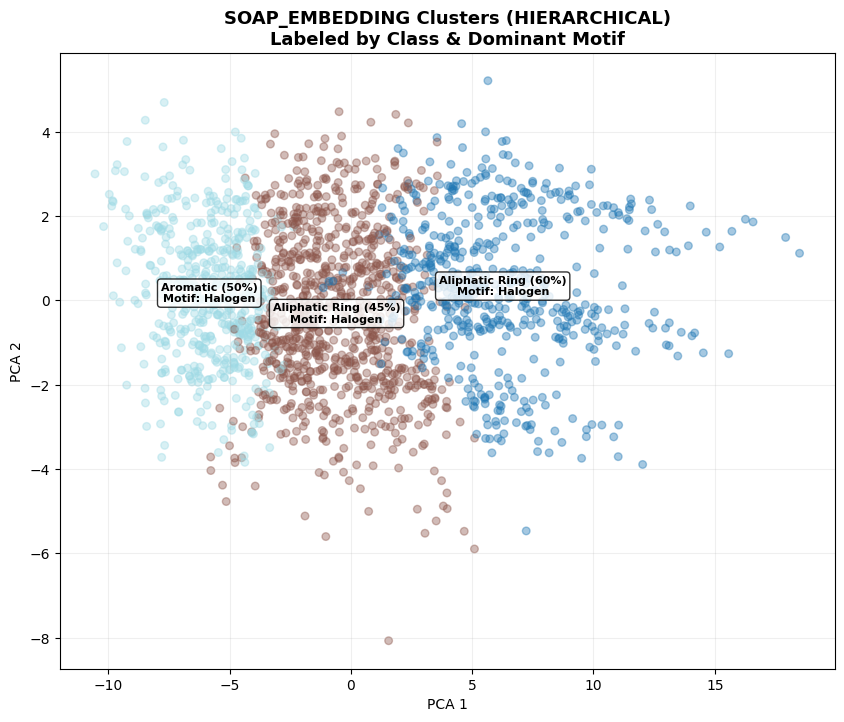

2026-02-11 15:28:57.430 | INFO     | __main__:clustering:19 - PCA reduced soap_embedding from 5740 to 10 dims. Exact variance kept: 95.37%


--- Running DBSCAN ---
Found 2 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0071
Silhouette Score: -0.1291
Calinski-Harabasz Score: 5.0194


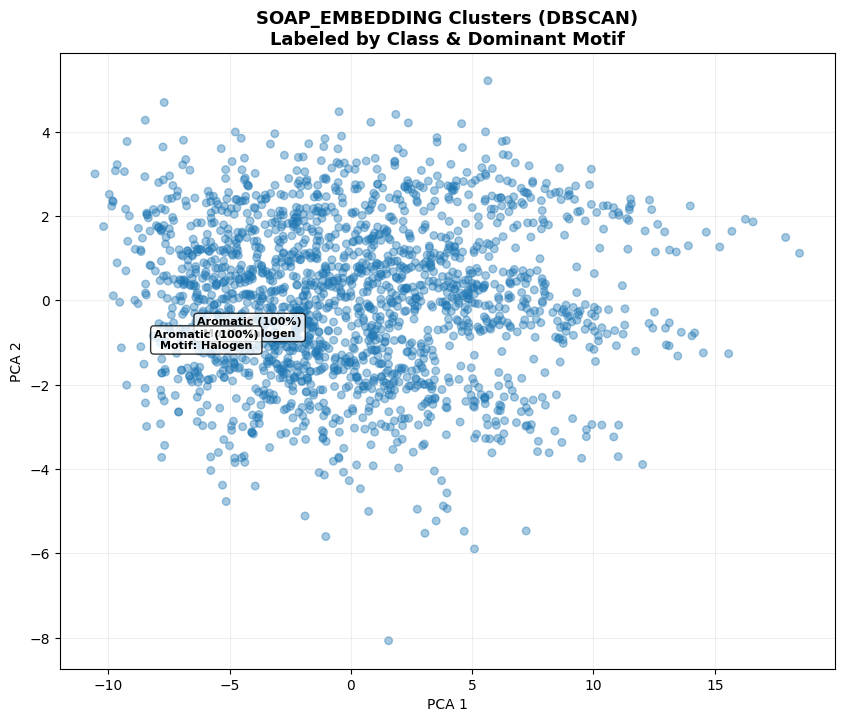

2026-02-11 15:28:57.564 | INFO     | __main__:clustering:19 - PCA reduced acsf_embedding from 65 to 3 dims. Exact variance kept: 95.32%


--- Running KMEANS ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.1160
Silhouette Score: 0.3272
Calinski-Harabasz Score: 1821.4094


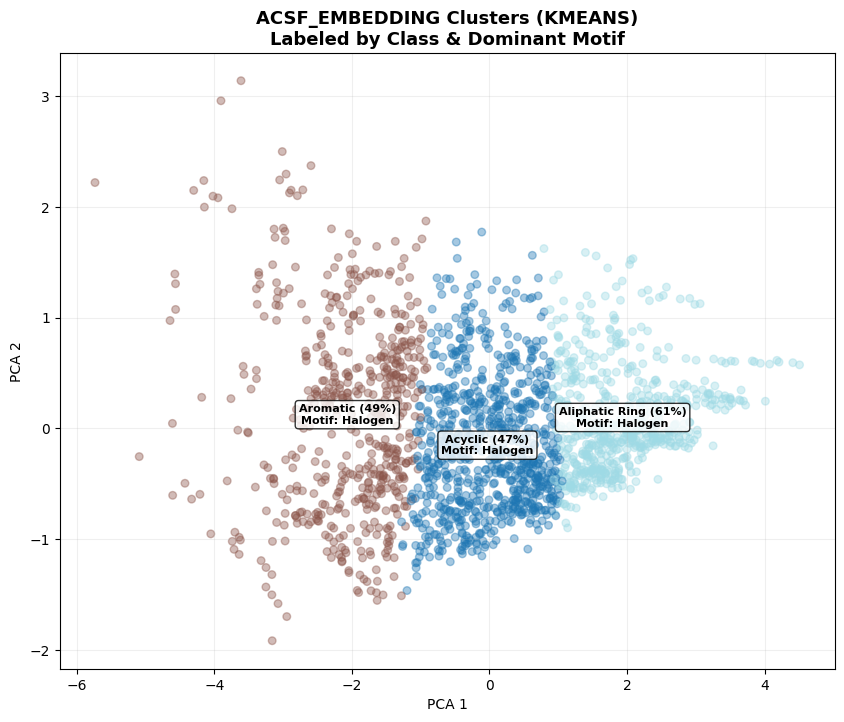

2026-02-11 15:28:57.707 | INFO     | __main__:clustering:19 - PCA reduced acsf_embedding from 65 to 3 dims. Exact variance kept: 95.32%


--- Running HIERARCHICAL ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0927
Silhouette Score: 0.2918
Calinski-Harabasz Score: 1529.5019


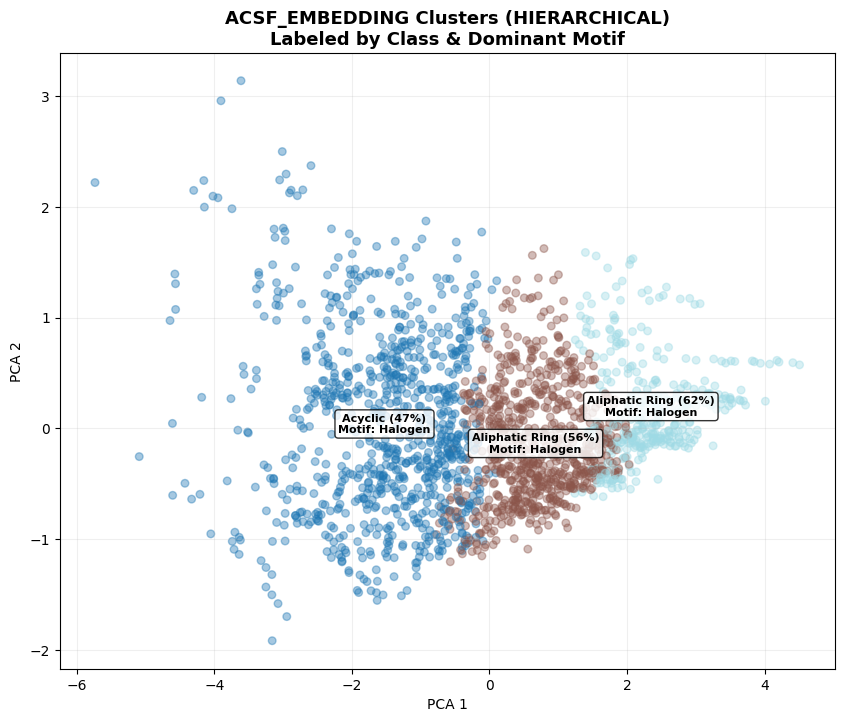

2026-02-11 15:28:57.845 | INFO     | __main__:clustering:19 - PCA reduced acsf_embedding from 65 to 3 dims. Exact variance kept: 95.32%


--- Running DBSCAN ---
Found 3 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0253
Silhouette Score: 0.3016
Calinski-Harabasz Score: 80.0517


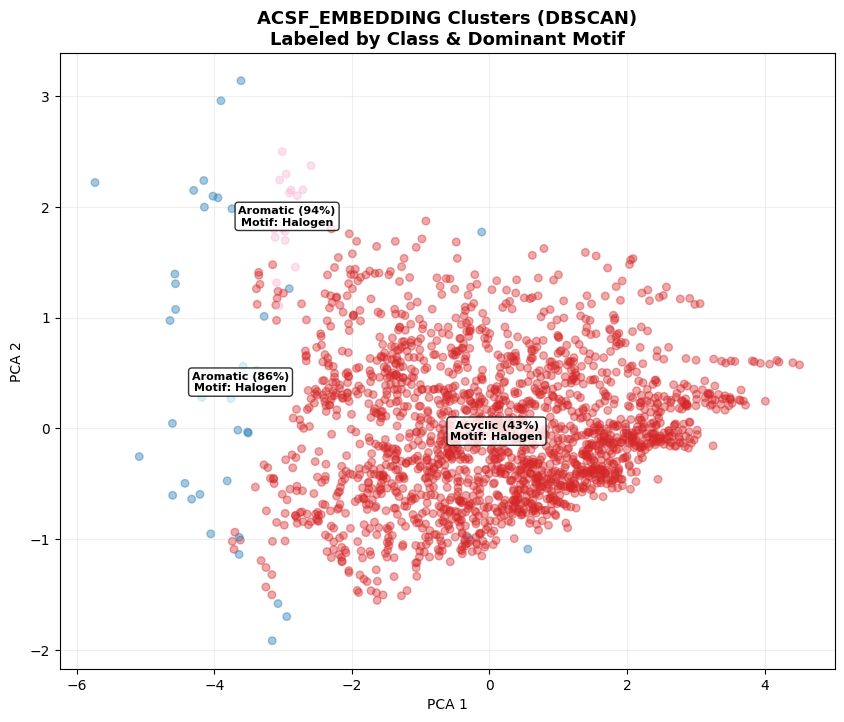

In [40]:
clustering(do_pca=True)